<a href="https://colab.research.google.com/github/tripathiosho/ImportantNotebooks/blob/main/anomaly_dectection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (12,8)

In [ ]:
!gdown 1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg

Downloading...
From: https://drive.google.com/uc?id=1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg
To: /content/AnomalyDetection.csv
100% 33.0k/33.0k [00:00<00:00, 78.4MB/s]


In [ ]:
df = pd.read_csv('/content/AnomalyDetection.csv')
df.head()

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432


Text(0, 0.5, 'Price')

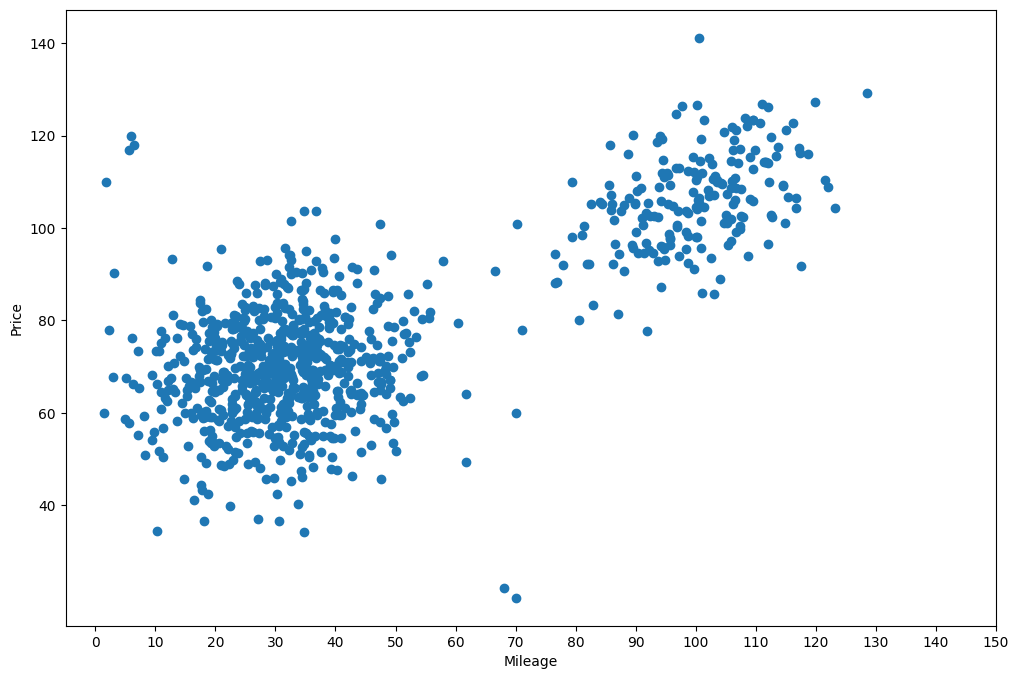

In [ ]:
plt.scatter(df.Mileage, df.Price)
plt.yticks(np.arange(40,160,20))
plt.xticks(np.arange(0,160,10))
plt.xlabel('Mileage')
plt.ylabel('Price')

## Difference between Novelty, Anomaly and Outlier.

| Term                  | What It Detects                                                   | When It’s Seen                                                         | Example Use Case                          |
| --------------------- | ----------------------------------------------------------------- | ---------------------------------------------------------------------- | ----------------------------------------- |
| **Anomaly Detection** | Points that don’t fit the normal pattern                          | Model is trained on mostly normal data, but may include some anomalies | Detecting fraud in transactions           |
| **Novelty Detection** | New or unseen patterns (not present in training)                  | Model is trained *only on normal data*                                 | Detecting new types of network intrusions |
| **Outlier Detection** | Statistically rare or extreme data points (in the dataset itself) | Purely statistical, often without labels                               | Removing extreme values before training   |


## Quiz

Suppose a distribution with a few data points has a certain mean and standard deviation. If an extreme data point with a positive value is added to the distribution, what will happen to the mean and standard deviation of the distribution parameters?

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
clf = IsolationForest(random_state=0, contamination = 0.08).fit_predict(df.iloc[:, :-1])
df['is_outlier_if'] = clf

In [ ]:
df["is_outlier_if"].unique()

array([ 1, -1])

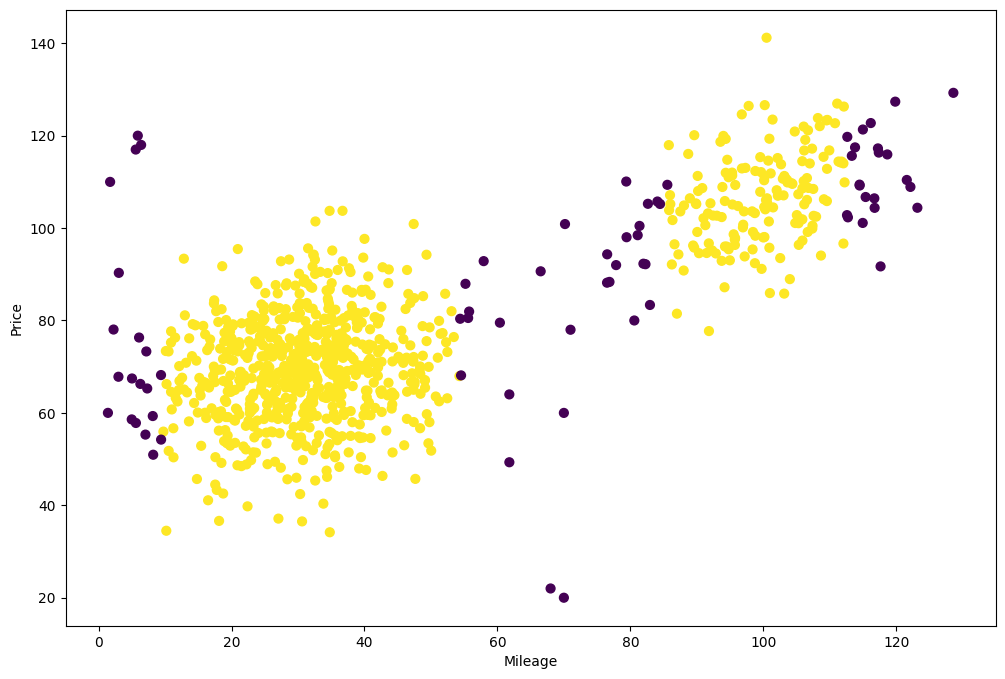

In [ ]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_if'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

## One class SVM

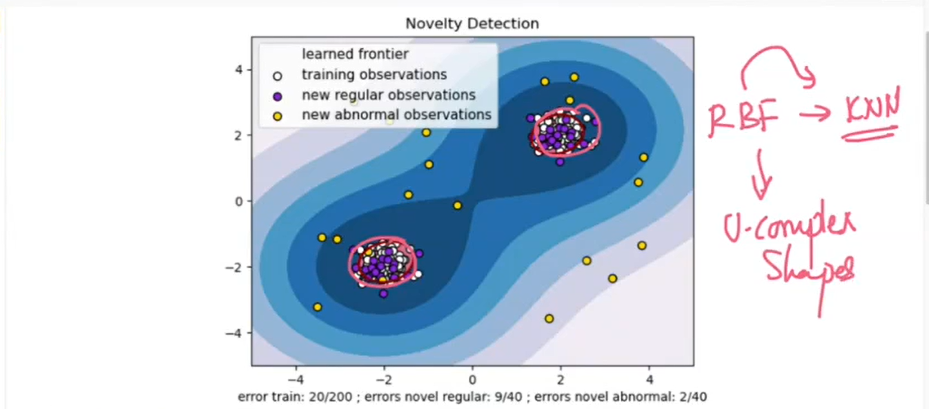

In [ ]:
from sklearn.svm import OneClassSVM

In [ ]:
ocsvm = OneClassSVM(kernel = 'rbf', gamma = 0.1, nu = 0.05).fit_predict(df.iloc[:, :2])
df['is_outlier_svm'] = ocsvm

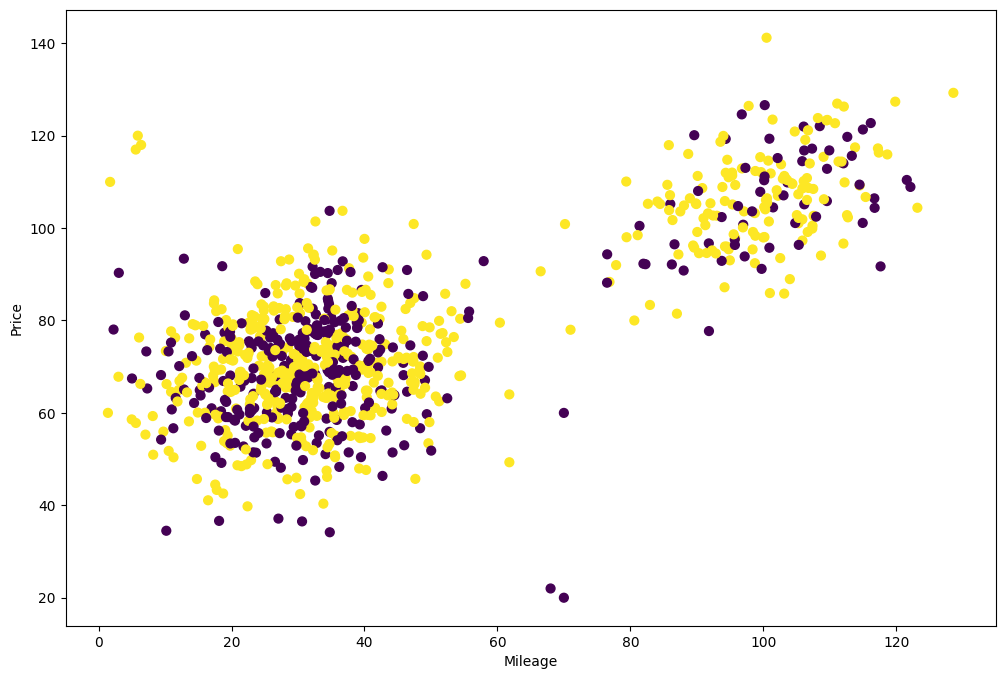

In [ ]:
plt.scatter(df['Mileage'], df['Price'], s=40, c=df['is_outlier_svm'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

Disdvantages of One-Class SVMs
As good as One-Class SVMs might sound, they have some limitations.
They are:

1. Kernel Selection (RBF: default)
2. As the number of datapoints (
n * n) increases, time complexity increases
3. All disadvantages of SVMs

## Local Outlier Factor

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor(n_neighbors=100, contamination=0.065).fit_predict(df.iloc[:, :2])
df['is_outlier_lof'] = clf

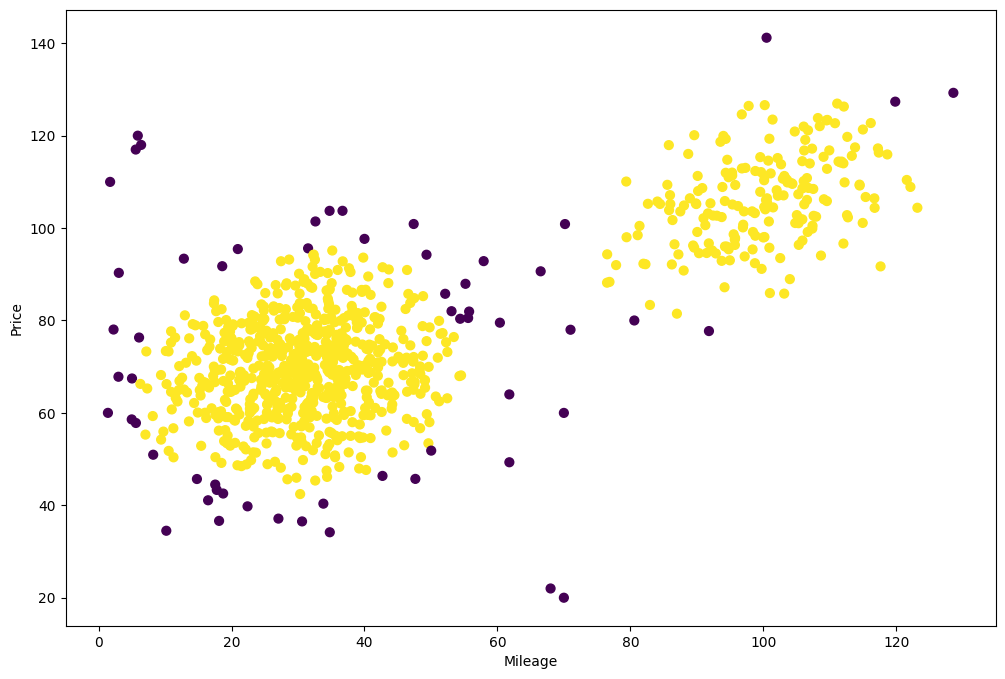

In [ ]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_lof'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [ ]:
df["is_outlier_lof"].unique()

array([ 1, -1])